In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import glob
import geopandas as gpd

In [3]:
n = 1
folders = [f"../../data/flask/GNSS/jug{n}" for n in range(1,4)]
file_lists = [glob.glob(f"{folder}/*.LC") for folder in folders]
file_lists = [sorted(flist) for flist in file_lists]
file_lists

[['../../data/flask/GNSS/jug1/TRACK_2024_336_sgp1.NEU.jug1.LC',
  '../../data/flask/GNSS/jug1/TRACK_2024_337_sgp1.NEU.jug1.LC',
  '../../data/flask/GNSS/jug1/TRACK_2024_338_sgp1.NEU.jug1.LC',
  '../../data/flask/GNSS/jug1/TRACK_2024_339_sgp1.NEU.jug1.LC',
  '../../data/flask/GNSS/jug1/TRACK_2024_340_sgp1.NEU.jug1.LC',
  '../../data/flask/GNSS/jug1/TRACK_2024_341_sgp1.NEU.jug1.LC',
  '../../data/flask/GNSS/jug1/TRACK_2024_342_sgp1.NEU.jug1.LC',
  '../../data/flask/GNSS/jug1/TRACK_2024_343_sgp1.NEU.jug1.LC'],
 ['../../data/flask/GNSS/jug2/TRACK_2024_338_sgp1.NEU.jug2.LC',
  '../../data/flask/GNSS/jug2/TRACK_2024_339_sgp1.NEU.jug2.LC',
  '../../data/flask/GNSS/jug2/TRACK_2024_340_sgp1.NEU.jug2.LC',
  '../../data/flask/GNSS/jug2/TRACK_2024_341_sgp1.NEU.jug2.LC',
  '../../data/flask/GNSS/jug2/TRACK_2024_342_sgp1.NEU.jug2.LC',
  '../../data/flask/GNSS/jug2/TRACK_2024_343_sgp1.NEU.jug2.LC',
  '../../data/flask/GNSS/jug2/TRACK_2024_344_sgp1.NEU.jug2.LC',
  '../../data/flask/GNSS/jug2/TRACK_202

In [4]:
df = pd.read_fwf(file_lists[0][0],  header = 0, skiprows=[1])

In [5]:
df = df.rename(columns ={'+-': 'dNorth_uncertainty', '+-.': 'dEast_uncertainty','+-.2': 'dHeight_uncertainty','Fract DOY': 'doy'})
df

,* YY,MM,DD,HR,MIN,Sec,dNorth,dNorth_uncertainty,dEast,+-.1,...,dHeight_uncertainty,RMS,#,Atm,+-.3,doy,Epoch,#BF,NotF,Rho_UA
0,2024,12,1,16,30,29.999999,-26321.7823,0.0053,-44020.0001,0.0037,...,0.0101,3.86,7,-47.09,11.80,336.687847,1,16,1 K,-0.009
1,2024,12,1,16,31,0.000000,-26321.7823,0.0053,-44020.0001,0.0036,...,0.0100,4.29,7,-47.09,11.80,336.688194,2,16,1 S,-0.009
2,2024,12,1,16,31,30.000000,-26321.7822,0.0052,-44020.0000,0.0035,...,0.0100,5.88,7,-47.09,11.80,336.688542,3,16,1 S,-0.009
3,2024,12,1,16,32,0.000000,-26321.7820,0.0051,-44020.0000,0.0034,...,0.0099,7.76,7,-47.09,11.80,336.688889,4,16,1 S,-0.009
4,2024,12,1,16,32,30.000000,-26321.7819,0.0050,-44019.9999,0.0033,...,0.0099,7.24,7,-47.09,11.80,336.689236,5,16,1 S,-0.009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
894,2024,12,1,23,57,30.000000,-26321.7785,0.0055,-44019.9833,0.0032,...,0.0090,5.03,6,-47.29,11.71,336.998264,895,14,1 S,0.002
895,2024,12,1,23,58,0.000000,-26321.7785,0.0056,-44019.9833,0.0033,...,0.0090,6.85,6,-47.29,11.71,336.998611,896,14,1 S,0.002
896,2024,12,1,23,58,30.000000,-26321.7785,0.0057,-44019.9833,0.0034,...,0.0091,5.31,6,-47.29,11.71,336.998958,897,14,1 S,0.002
897,2024,12,1,23,59,0.000000,-26321.7786,0.0057,-44019.9833,0.0035,...,0.0091,4.57,6,-47.29,11.71,336.999306,898,14,1 S,0.002


In [6]:
def load_jug_files(f):

    dfs = [pd.read_fwf(f,  header = 0, skiprows=[1]) for f in f]
    df = pd.concat(dfs)
    df = df.rename(columns ={'+-': 'dNorth_uncertainty', '+-.1': 'dEast_uncertainty','+-.2': 'dHeight_uncertainty',"Fract DOY": 'DOY'})
    df.set_index('DOY', inplace=True)

    return df.to_xarray()

site1 = load_jug_files(file_lists[0])
site2 = load_jug_files(file_lists[1])
site3 = load_jug_files(file_lists[2])



In [7]:
site1

<xarray.Dataset> Size: 3MB
Dimensions:              (DOY: 19788)
Coordinates:
  * DOY                  (DOY) float64 158kB 336.7 336.7 336.7 ... 343.6 343.6
Data variables: (12/20)
    * YY                 (DOY) int64 158kB 2024 2024 2024 ... 2024 2024 2024
    MM                   (DOY) int64 158kB 12 12 12 12 12 12 ... 12 12 12 12 12
    DD                   (DOY) int64 158kB 1 1 1 1 1 1 1 1 1 ... 8 8 8 8 8 8 8 8
    HR                   (DOY) int64 158kB 16 16 16 16 16 16 ... 14 14 14 14 14
    MIN                  (DOY) int64 158kB 30 31 31 32 32 33 ... 22 22 23 23 24
    Sec                  (DOY) float64 158kB 30.0 0.0 30.0 ... 0.0 30.0 1e-06
    ...                   ...
    Atm                  (DOY) float64 158kB -47.09 -47.09 ... -174.4 -174.4
    +-.3                 (DOY) float64 158kB 11.8 11.8 11.8 ... 8.97 8.97 8.97
    Epoch                (DOY) int64 158kB 1 2 3 4 5 ... 1726 1727 1728 1729
    #BF                  (DOY) int64 158kB 16 16 16 16 16 16 ... 20 20 20 20 20
    NotF                 (DOY) object 158kB '1 K' '1 S' '1 S' ... '2 S' '2 S'
    Rho_UA               (DOY) float64 158kB -0.009 -0.009 ... -0.121 -0.121

In [8]:
FG_AWS = xr.load_dataset('../aws/aws_season_1.nc')  # created with code/aws/season_1.ipynb
FG_AWS["doy_frac"] = (
    FG_AWS["time"].dt.dayofyear
    + (FG_AWS["time"].dt.hour*3600
       + FG_AWS["time"].dt.minute*60
       + FG_AWS["time"].dt.second
       + FG_AWS["time"].dt.microsecond/1e6) / 86400
)
FG_AWS = FG_AWS.assign_coords({'doy_frac': FG_AWS['doy_frac']})

Text(0.5, 0, 'site 3 uncertainties (m)')

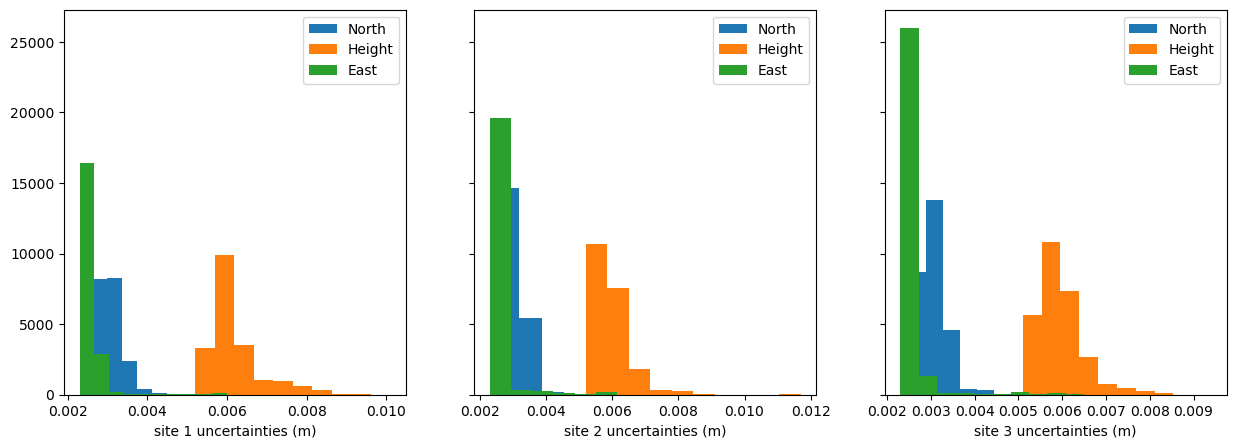

In [9]:
fig, ax = plt.subplots(1,3, figsize = (15,5), sharey= True)
site1.dNorth_uncertainty.plot.hist(ax = ax[0], label = 'North')
site1.dHeight_uncertainty.plot.hist(ax = ax[0], label = 'Height')
site1.dEast_uncertainty.plot.hist(ax = ax[0], label = 'East')
ax[0].legend()
ax[0].set_xlabel('site 1 uncertainties (m)')

site2.dNorth_uncertainty.plot.hist(ax = ax[1], label = 'North')
site2.dHeight_uncertainty.plot.hist(ax = ax[1], label = 'Height')
site2.dEast_uncertainty.plot.hist(ax = ax[1], label = 'East')
ax[1].legend()
ax[1].set_xlabel('site 2 uncertainties (m)')

site3.dNorth_uncertainty.plot.hist(ax = ax[2], label = 'North')
site3.dHeight_uncertainty.plot.hist(ax = ax[2], label = 'Height')
site3.dEast_uncertainty.plot.hist(ax = ax[2], label = 'East')
ax[2].legend()
ax[2].set_xlabel('site 3 uncertainties (m)')

In [10]:
def subtract0(data):
    return data - data.isel(DOY= 0)

Text(0.5, 1.0, 'GNSS site 3 displacements')

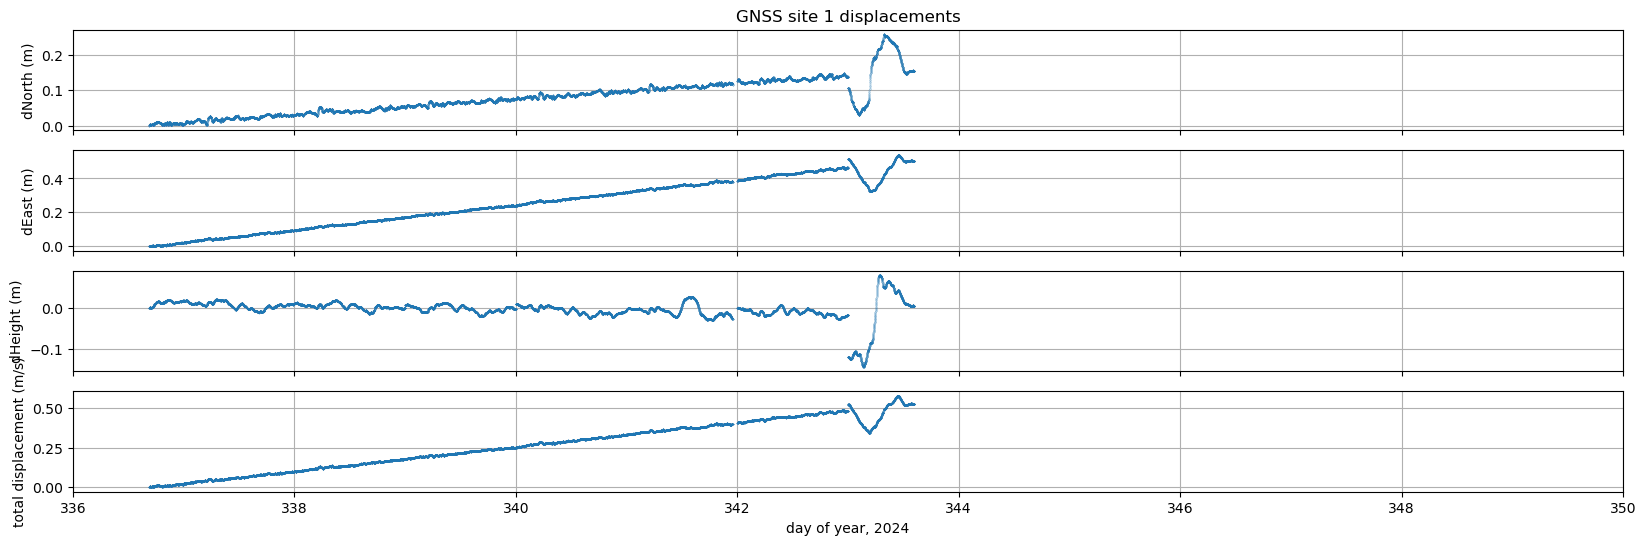

<Figure size 1000x600 with 0 Axes>

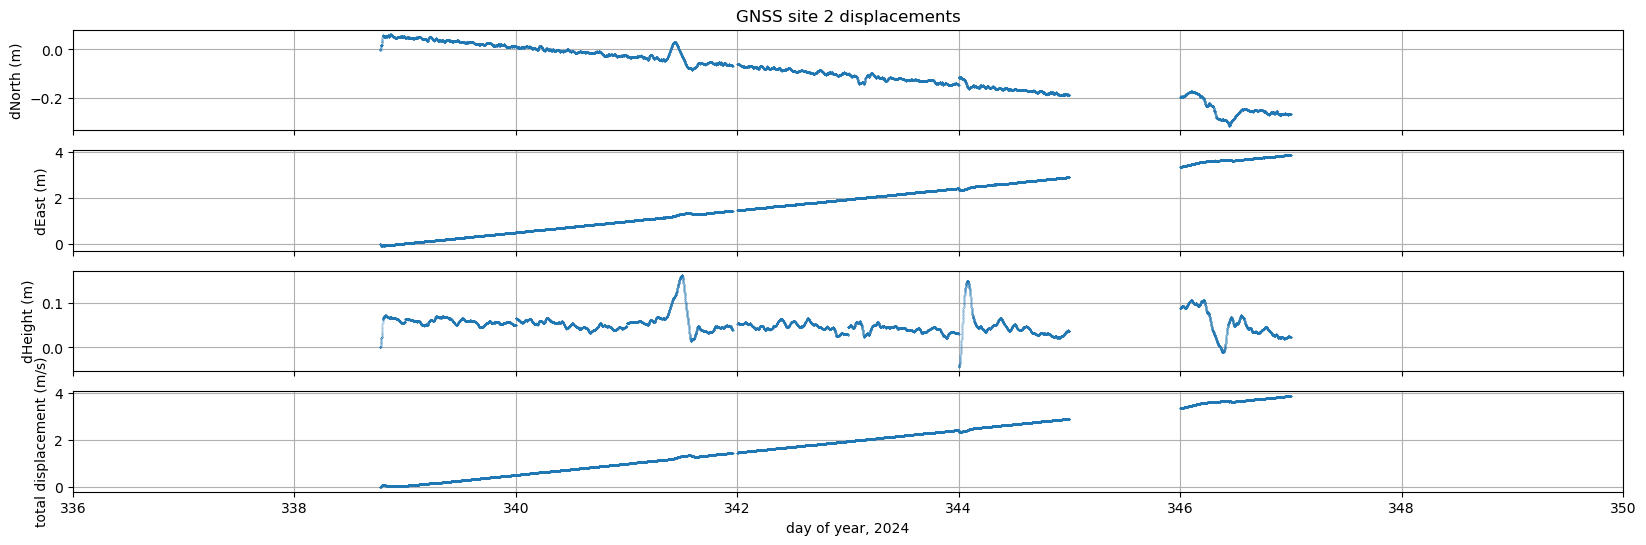

<Figure size 1000x600 with 0 Axes>

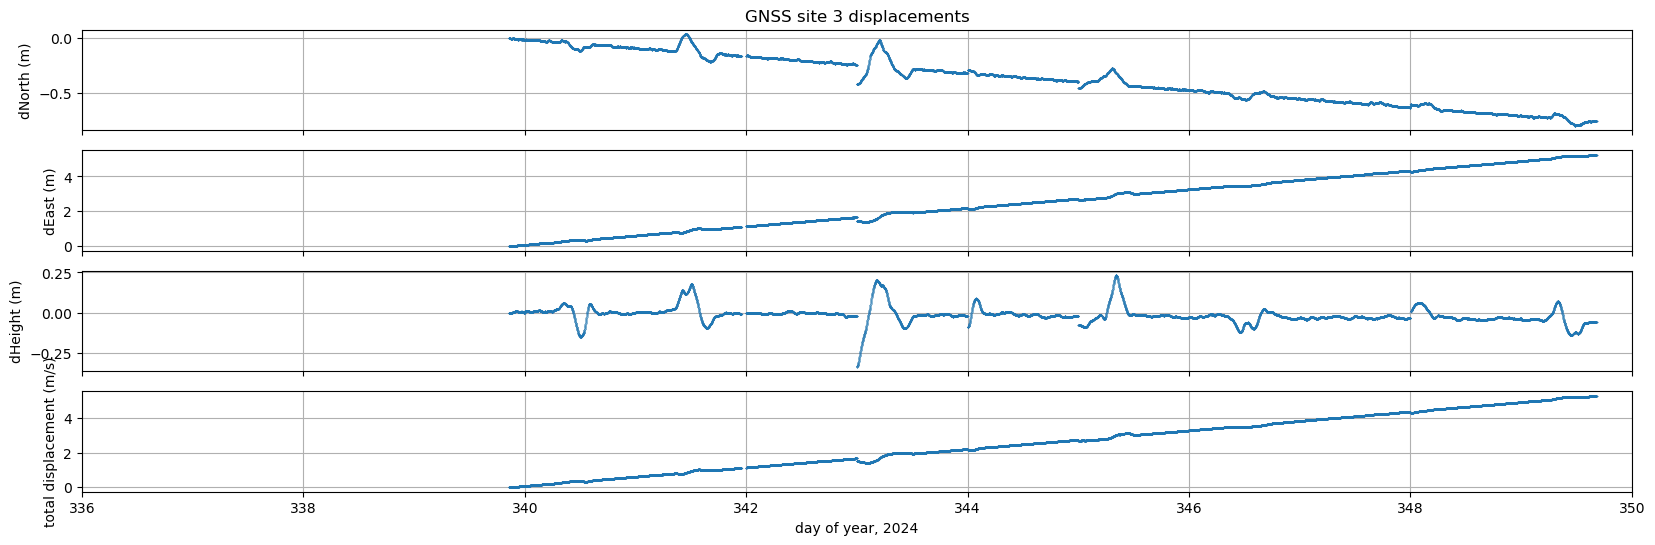

<Figure size 1000x600 with 0 Axes>

In [11]:
def plot_NEU(da):
    fig, ax = plt.subplots(4,1,figsize=(20,6), sharex=True)
    plt.figure(figsize=(10,6))
    dNorth = subtract0(da.dNorth)
    dEast = subtract0(da.dEast)
    dHeight = subtract0(da.dHeight)

    total = (dEast**2 + dNorth**2)**0.5

    dNorth.plot.line(ax = ax[0], label='North', marker = '.', linestyle = 'None', markersize = 0.2)
    dEast.plot(ax = ax[1], label='East', marker = '.', linestyle = 'None', markersize = 0.2)
    dHeight.plot(ax = ax[2], label='Up', marker = '.', linestyle = 'None', markersize = 0.2)
    total.plot(ax = ax[3], label='Speed', marker = '.', linestyle = 'None', markersize = 0.2)

    ax[0].grid()
    ax[1].grid()
    ax[2].grid()
    ax[3].grid()

    ax[0].set_xlim(336, 350)
    ax[1].set_xlim(336, 350)
    ax[2].set_xlim(336, 350)
    ax[3].set_xlim(336, 350)

    ax[0].set_ylabel('dNorth (m)')
    ax[1].set_ylabel('dEast (m)')
    ax[2].set_ylabel('dHeight (m)')
    ax[3].set_ylabel('total displacement (m/s)')

    ax[0].set_xlabel('')
    ax[1].set_xlabel('')
    ax[2].set_xlabel('')
    ax[3].set_xlabel('day of year, 2024')

    #ax[0].set_ylim(-0.7, 0.3)
    return fig, ax

fig, ax = plot_NEU(site1)
ax[0].set_title('GNSS site 1 displacements')
fig, ax = plot_NEU(site2)
ax[0].set_title('GNSS site 2 displacements')
fig, ax = plot_NEU(site3)
ax[0].set_title('GNSS site 3 displacements')

(336.0, 350.0)

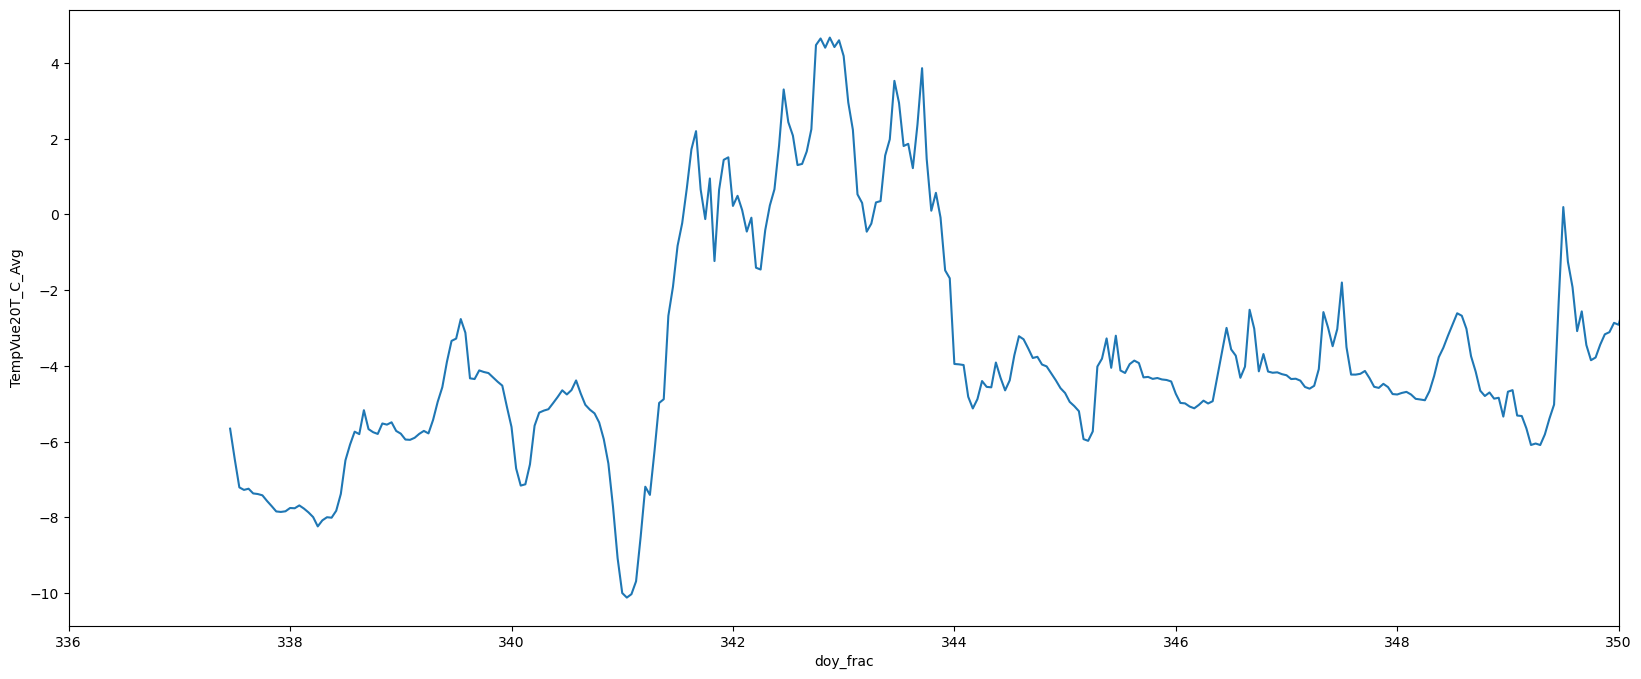

In [12]:
fig, ax = plt.subplots(figsize=(20,8))
FG_AWS.TempVue20T_C_Avg.plot(x = 'doy_frac')
ax.set_xlim(336, 350)


Text(0.5, 0, 'day of year, 2024')

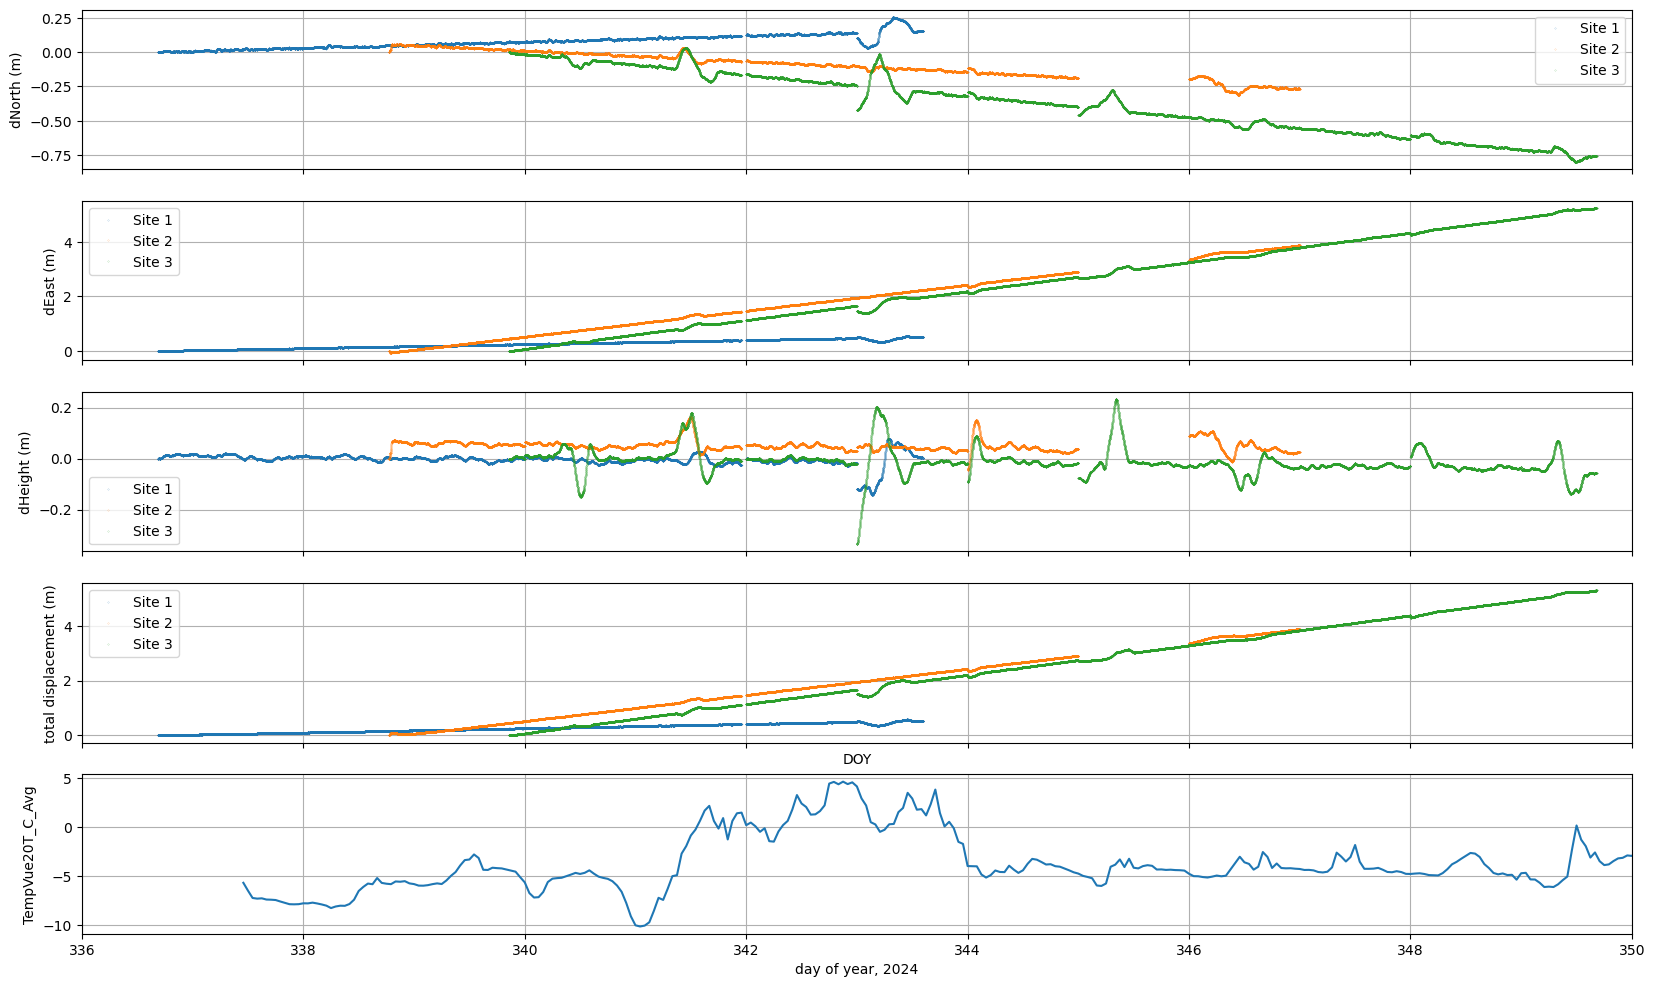

In [13]:



fig, ax = plt.subplots(5,1,figsize=(20,12), sharex=True)

subtract0(site1.dNorth).plot(ax = ax[0], label='Site 1', marker = '.', linestyle = 'None', markersize = 0.2)
subtract0(site2.dNorth).plot(ax = ax[0], label='Site 2', marker = '.', linestyle = 'None', markersize = 0.2)
subtract0(site3.dNorth).plot(ax = ax[0], label='Site 3', marker = '.', linestyle = 'None', markersize = 0.2)

ax[0].legend()
ax[0].set_ylabel('dNorth (m)')

subtract0(site1.dEast).plot(ax = ax[1], label='Site 1', marker = '.', linestyle = 'None', markersize = 0.2)
subtract0(site2.dEast).plot(ax = ax[1], label='Site 2', marker = '.', linestyle = 'None', markersize = 0.2)
subtract0(site3.dEast).plot(ax = ax[1], label='Site 3', marker = '.', linestyle = 'None', markersize = 0.2)

ax[1].legend()
ax[1].set_ylabel('dEast (m)')

subtract0(site1.dHeight).plot(ax = ax[2], label='Site 1', marker = '.', linestyle = 'None', markersize = 0.2)
subtract0(site2.dHeight).plot(ax = ax[2], label='Site 2', marker = '.', linestyle = 'None', markersize = 0.2)
subtract0(site3.dHeight).plot(ax = ax[2], label='Site 3', marker = '.', linestyle = 'None', markersize = 0.2)

ax[2].legend()
ax[2].set_ylabel('dHeight (m)')

total1 = (subtract0(site1.dEast)**2 + subtract0(site1.dNorth)**2)**0.5
total2 = (subtract0(site2.dEast)**2 + subtract0(site2.dNorth)**2)**0.5
total3 = (subtract0(site3.dEast)**2 + subtract0(site3.dNorth)**2)**0.5

total1.plot(ax = ax[3], label='Site 1', marker = '.', linestyle = 'None', markersize = 0.2)
total2.plot(ax = ax[3], label='Site 2', marker = '.', linestyle = 'None', markersize = 0.2)
total3.plot(ax = ax[3], label='Site 3', marker = '.', linestyle = 'None', markersize = 0.2)     
ax[3].legend()
ax[3].set_ylabel('total displacement (m)')

ax[0].grid()
ax[1].grid()
ax[2].grid()
ax[3].grid()
ax[4].grid()


FG_AWS.TempVue20T_C_Avg.plot(ax = ax[4],x = 'doy_frac')
ax[4].set_xlim(336, 350)

ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[2].set_xlabel('')

ax[4].set_xlabel('day of year, 2024')



Text(0, 0.5, 'dNorth (m)')

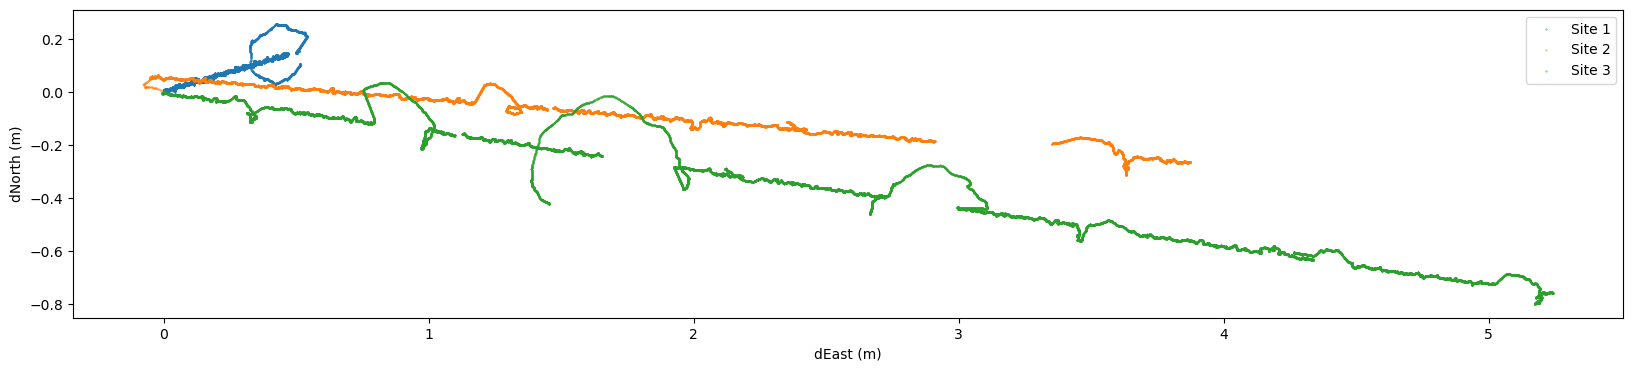

In [14]:
fig, ax = plt.subplots(figsize=(20,8))
plt.scatter(subtract0(site1.dEast), subtract0(site1.dNorth), s = 0.1, label = 'Site 1')
plt.scatter(subtract0(site2.dEast), subtract0(site2.dNorth), s = 0.1, label = 'Site 2')
plt.scatter(subtract0(site3.dEast), subtract0(site3.dNorth), s = 0.1, label = 'Site 3')
plt.legend()
ax.set_aspect('equal')
plt.xlabel('dEast (m)')
plt.ylabel('dNorth (m)')


Text(0, 0.5, 'dNorth (m)')

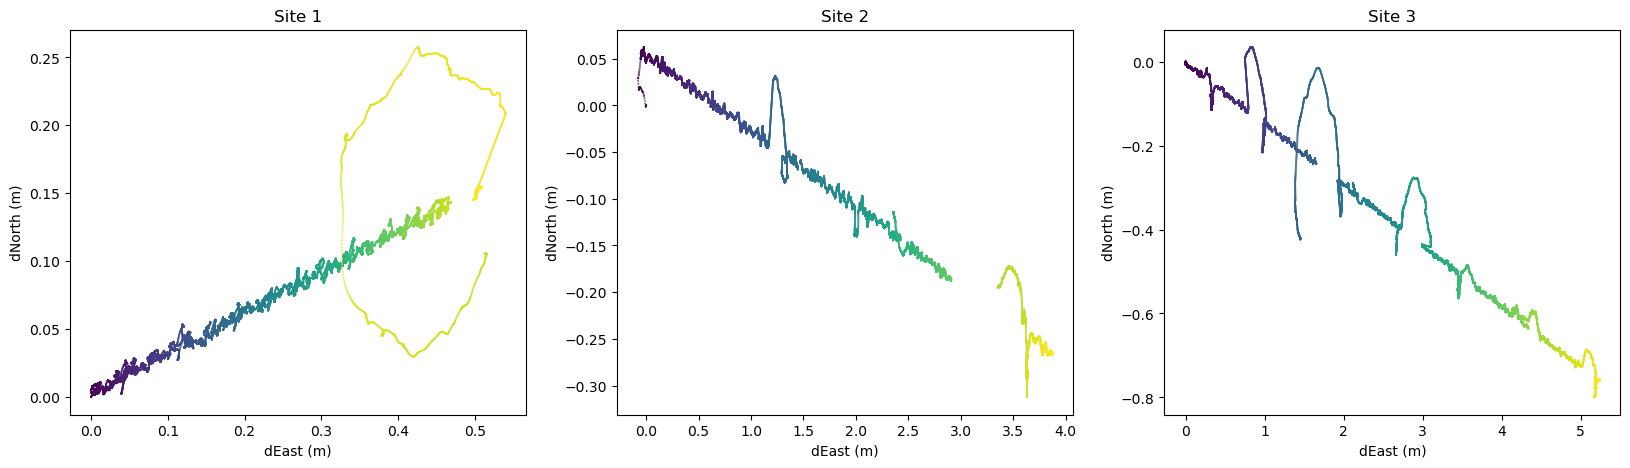

In [15]:
fig, ax = plt.subplots(1,3, figsize = (20,5))
ax[0].scatter(subtract0(site1.dEast), subtract0(site1.dNorth) , c = site1.DOY, s = 0.1)
ax[0].set_title('Site 1')
ax[0].set_xlabel('dEast (m)')
ax[0].set_ylabel('dNorth (m)')
# ax[0].colorbar()
ax[1].scatter(subtract0(site2.dEast), subtract0(site2.dNorth) , c = site2.DOY, s = 0.1)
ax[1].set_title('Site 2')
ax[1].set_xlabel('dEast (m)')
ax[1].set_ylabel('dNorth (m)')
# ax[1].colorbar()
ax[2].scatter(subtract0(site3.dEast), subtract0(site3.dNorth) , c = site3.DOY, s = 0.1)
ax[2].set_title('Site 3')
ax[2].set_xlabel('dEast (m)')
ax[2].set_ylabel('dNorth (m)')


In [157]:
# geometry = gpd.points_from_xy([-63.229], [-66.616])
# aws20_locations = gpd.GeoDataFrame(geometry=geometry, crs="EPSG:4326")

sgp1 = gpd.read_file("../../data/flask/GNSS/polenet_station_locations/SGP1.shp").to_crs(epsg=3031)

In [ ]:
sgp1.geometry.y.values + site1.dNorth

<xarray.DataArray 'dNorth' (DOY: 19788)> Size: 158kB
array([1250524.60531074, 1250524.60531074, 1250524.60541074, ...,
       1250524.75971074, 1250524.75971074, 1250524.75971074],
      shape=(19788,))
Coordinates:
  * DOY      (DOY) float64 158kB 336.7 336.7 336.7 336.7 ... 343.6 343.6 343.6

In [ ]:
(site1.dEast**2 + site1.dNorth**2)**0.5

<xarray.DataArray (DOY: 19788)> Size: 158kB
array([51289.34228719, 51289.34228719, 51289.34215004, ...,
       51288.82979531, 51288.82979531, 51288.82979531], shape=(19788,))
Coordinates:
  * DOY      (DOY) float64 158kB 336.7 336.7 336.7 336.7 ... 343.6 343.6 343.6

In [177]:
d = pd.to_datetime("2024-12-01")
doy = d.dayofyear
print(f'site 1 was installed on day {doy}')

site 1 was installed on day 336


In [178]:
d = pd.to_datetime("2024-12-03")
doy = d.dayofyear
print(f'site 2 was installed on day {doy}')

site 2 was installed on day 338


In [179]:
d = pd.to_datetime("2024-12-13")
doy = d.dayofyear
print(f'site 2 data goes through to about {doy}')

site 2 data goes through to about 348


In [181]:
d = pd.to_datetime("2024-12-4")
doy = d.dayofyear
print(f'site 3 was installed on day {doy}')

site 3 was installed on day 339


In [182]:
d = pd.to_datetime("2024-12-15")
doy = d.dayofyear
print(f'site 3 data goes through to about {doy}')

site 3 data goes through to about 350


In [ ]:
site1

<xarray.Dataset> Size: 3MB
Dimensions:    (Fract DOY: 19788)
Coordinates:
  * Fract DOY  (Fract DOY) float64 158kB 336.7 336.7 336.7 ... 343.6 343.6 343.6
Data variables: (12/20)
    * YY       (Fract DOY) int64 158kB 2024 2024 2024 2024 ... 2024 2024 2024
    MM         (Fract DOY) int64 158kB 12 12 12 12 12 12 ... 12 12 12 12 12 12
    DD         (Fract DOY) int64 158kB 1 1 1 1 1 1 1 1 1 1 ... 8 8 8 8 8 8 8 8 8
    HR         (Fract DOY) int64 158kB 16 16 16 16 16 16 ... 14 14 14 14 14 14
    MIN        (Fract DOY) int64 158kB 30 31 31 32 32 33 ... 21 22 22 23 23 24
    Sec        (Fract DOY) float64 158kB 30.0 0.0 30.0 0.0 ... 0.0 30.0 1e-06
    ...         ...
    Atm        (Fract DOY) float64 158kB -47.09 -47.09 -47.09 ... -174.4 -174.4
    +-.3       (Fract DOY) float64 158kB 11.8 11.8 11.8 11.8 ... 8.97 8.97 8.97
    Epoch      (Fract DOY) int64 158kB 1 2 3 4 5 6 ... 1725 1726 1727 1728 1729
    #BF        (Fract DOY) int64 158kB 16 16 16 16 16 16 ... 20 20 20 20 20 20
    NotF       (Fract DOY) object 158kB '1 K' '1 S' '1 S' ... '2 S' '2 S' '2 S'
    Rho_UA     (Fract DOY) float64 158kB -0.009 -0.009 -0.009 ... -0.121 -0.121

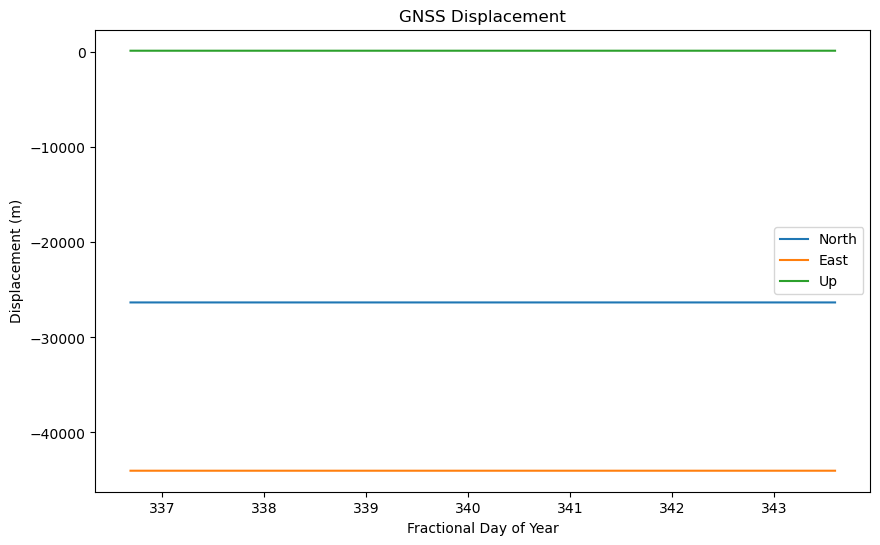

In [ ]:
plot_NEU(site1)

<Axes: xlabel='Fract DOY'>

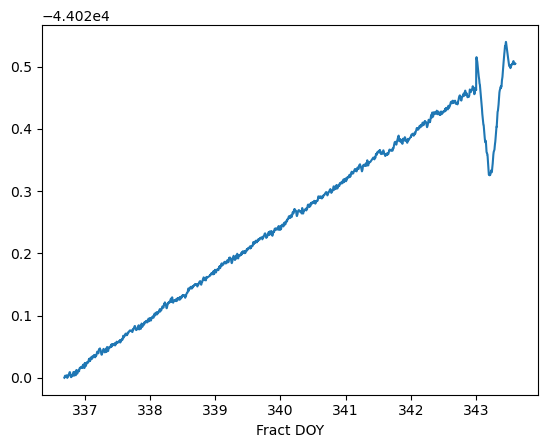

In [45]:
df.dEast.plot()

<Axes: xlabel='Fract DOY'>

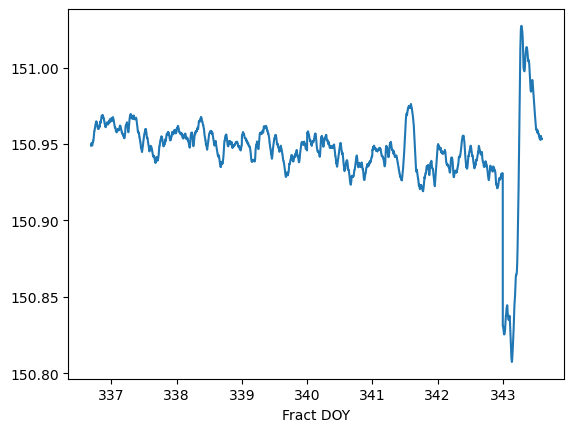

In [46]:
df.dHeight.plot()

In [47]:
ds=df.to_xarray()
ds

<xarray.Dataset> Size: 3MB
Dimensions:    (Fract DOY: 19788)
Coordinates:
  * Fract DOY  (Fract DOY) float64 158kB 336.7 336.7 336.7 ... 343.6 343.6 343.6
Data variables: (12/20)
    * YY       (Fract DOY) int64 158kB 2024 2024 2024 2024 ... 2024 2024 2024
    MM         (Fract DOY) int64 158kB 12 12 12 12 12 12 ... 12 12 12 12 12 12
    DD         (Fract DOY) int64 158kB 1 1 1 1 1 1 1 1 1 1 ... 8 8 8 8 8 8 8 8 8
    HR         (Fract DOY) int64 158kB 16 16 16 16 16 16 ... 14 14 14 14 14 14
    MIN        (Fract DOY) int64 158kB 30 31 31 32 32 33 ... 21 22 22 23 23 24
    Sec        (Fract DOY) float64 158kB 30.0 0.0 30.0 0.0 ... 0.0 30.0 1e-06
    ...         ...
    Atm        (Fract DOY) float64 158kB -47.09 -47.09 -47.09 ... -174.4 -174.4
    +-.3       (Fract DOY) float64 158kB 11.8 11.8 11.8 11.8 ... 8.97 8.97 8.97
    Epoch      (Fract DOY) int64 158kB 1 2 3 4 5 6 ... 1725 1726 1727 1728 1729
    #BF        (Fract DOY) int64 158kB 16 16 16 16 16 16 ... 20 20 20 20 20 20
    NotF       (Fract DOY) object 158kB '1 K' '1 S' '1 S' ... '2 S' '2 S' '2 S'
    Rho_UA     (Fract DOY) float64 158kB -0.009 -0.009 -0.009 ... -0.121 -0.121

In [ ]:
ds = xr.open_mfdataset(f"{folder}/*.LC", combine='by_coords')

ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'scipy', 'rasterio', 'zarr']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html